# Bond Trading Desk — Morning Workflow

A rates trader's 7:00 AM routine: market setup, rich/cheap screen, trade construction, callable OAS, repo financing, risk snapshot.

In [1]:
import sys, os, math
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "python"))

import numpy as np
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta

from pricebook.bootstrap import bootstrap
from pricebook.bond import FixedRateBond
from pricebook.bond_trading_desk import bond_risk_metrics, bond_carry_roll
from pricebook.benchmark_bonds import (
    create_ust_universe, fitted_curve_nss,
    duration_neutral_spread, butterfly_trade, barbell_vs_bullet,
    carry_ranking, roll_down_ranking, rv_scorecard,
)
from pricebook.repo_curve import build_repo_curve, forward_repo_rate, special_gc_spread, repo_carry_from_curve
from pricebook.callable_bond_desk import callable_bond_analytics
from pricebook.treasury_quoting import to_32nds
from pricebook.viz import configure_theme, greeks_profile, sensitivity_grid, pnl_distribution
from pricebook.viz._backend import apply_theme, create_figure

configure_theme(seaborn_style="whitegrid", seaborn_context="notebook")
print("Pricebook bond desk loaded.")

Pricebook bond desk loaded.


## 1. Market Setup — SOFR curve + UST benchmark universe

In [2]:
REF = date(2024, 7, 15)

# SOFR/OIS curve from market
deposits = [(REF + relativedelta(months=1), 0.0530), (REF + relativedelta(months=3), 0.0528),
            (REF + relativedelta(months=6), 0.0515)]
swaps = [(REF + relativedelta(years=y), r) for y, r in
         [(1, 0.0490), (2, 0.0455), (3, 0.0435), (5, 0.0410), (7, 0.0400),
          (10, 0.0390), (20, 0.0405), (30, 0.0415)]]
curve = bootstrap(REF, deposits, swaps)

# UST benchmark yields (as-of morning)
ust_yields = {2: 0.0460, 3: 0.0440, 5: 0.0415, 7: 0.0405, 10: 0.0395, 20: 0.0410, 30: 0.0420}
ust_coupons = {2: 0.0450, 3: 0.0425, 5: 0.0400, 7: 0.0375, 10: 0.0425, 20: 0.0400, 30: 0.0375}
universe = create_ust_universe(REF, ust_yields, coupons=ust_coupons)

# Repo curve (GC)
gc_curve = build_repo_curve(REF, {"ON": 0.0530, "1W": 0.0528, "1M": 0.0525,
                                    "3M": 0.0520, "6M": 0.0510, "1Y": 0.0490})

print(f"As-of: {REF}")
print(f"\n{'Tenor':>5}  {'Yield':>7}  {'Coupon':>7}  {'Price':>8}  {'32nds':>10}")
print(f"{'─'*5}  {'─'*7}  {'─'*7}  {'─'*8}  {'─'*10}")
for b in universe.bonds:
    print(f"{b.tenor:>5}Y  {b.market_yield*100:>6.2f}%  {b.bond.coupon_rate*100:>6.2f}%  {b.market_price:>8.3f}  {to_32nds(b.market_price):>10}")

As-of: 2024-07-15

Tenor    Yield   Coupon     Price       32nds
─────  ───────  ───────  ────────  ──────────
    2Y    4.60%    4.50%    99.823      99-26+
    3Y    4.40%    4.25%    99.595       99-19
    5Y    4.15%    4.00%    99.340       99-11
    7Y    4.05%    3.75%    98.197      98-06+
   10Y    3.95%    4.25%   102.470      102-15
   20Y    4.10%    4.00%    98.654       98-21
   30Y    4.20%    3.75%    92.372       92-12


## 2. Rich/Cheap Screen — NSS fitted curve + RV scorecard


      Bond  Rich/Cheap     Carry      Roll     Score    Signal
──────────  ──────────  ────────  ────────  ────────  ────────
    UST 2Y       +0.0bp     -6.1     +0.0     -6.1      SELL
   UST 20Y       +2.0bp    -10.1     +0.0     -8.2      SELL
    UST 3Y       -0.1bp     -8.1     +0.0     -8.2      SELL
    UST 7Y       +1.8bp    -11.9     +0.0    -10.1      SELL
    UST 5Y       -0.4bp    -10.2     +0.0    -10.5      SELL
   UST 30Y       -1.1bp    -10.2     +0.0    -11.2      SELL
   UST 10Y       -2.2bp     -9.2     +0.0    -11.5      SELL


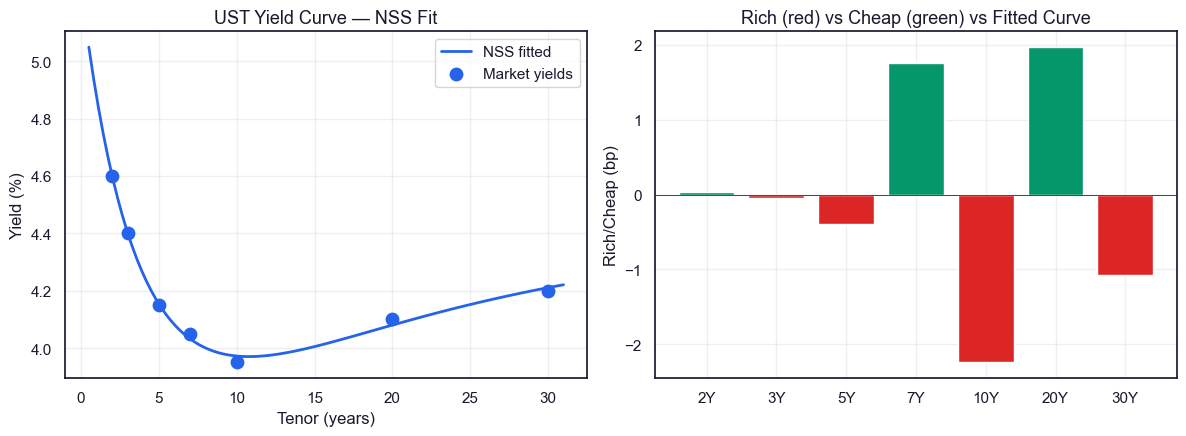

In [3]:
# Fit Nelson-Siegel-Svensson to benchmark yields
nss = fitted_curve_nss(universe)

# Plot fitted vs market
tenors_fine = np.linspace(0.5, 31, 100)
fitted_yields = [nss.yield_at(t) * 100 for t in tenors_fine]
market_t = [b.tenor for b in universe.bonds]
market_y = [b.market_yield * 100 for b in universe.bonds]

with apply_theme():
    fig, (ax1, ax2) = create_figure(2)

    ax1.plot(tenors_fine, fitted_yields, linewidth=2, label="NSS fitted")
    ax1.scatter(market_t, market_y, s=80, zorder=5, label="Market yields")
    ax1.set_xlabel("Tenor (years)")
    ax1.set_ylabel("Yield (%)")
    ax1.set_title("UST Yield Curve — NSS Fit")
    ax1.legend()

    # Rich/cheap = market - fitted (positive = cheap)
    rc_bps = [(b.market_yield - nss.yield_at(b.tenor)) * 1e4 for b in universe.bonds]
    colors = ['#dc2626' if v < 0 else '#059669' for v in rc_bps]
    ax2.bar([f"{b.tenor}Y" for b in universe.bonds], rc_bps, color=colors)
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.set_ylabel("Rich/Cheap (bp)")
    ax2.set_title("Rich (red) vs Cheap (green) vs Fitted Curve")

    fig.tight_layout()

# Full RV scorecard
scores = rv_scorecard(universe, nss, curve, repo_rate=0.0525)
print(f"\n{'Bond':>10}  {'Rich/Cheap':>10}  {'Carry':>8}  {'Roll':>8}  {'Score':>8}  {'Signal':>8}")
print(f"{'─'*10}  {'─'*10}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}")
for s in scores:
    rc = s.details["rich_cheap_bps"]
    signal = "BUY" if s.score > 2 else "SELL" if s.score < -2 else "HOLD"
    print(f"{s.label:>10}  {rc:>+9.1f}bp  {s.details['carry_bps']:>+7.1f}  {s.details['roll_bps']:>+7.1f}  {s.score:>+7.1f}  {signal:>8}")

## 3. Trade Construction — Steepener, butterfly, barbell vs bullet

In [4]:
# 2s10s steepener
spread_2s10s = duration_neutral_spread(universe, 2, 10, curve, notional=10_000_000)
print("═" * 60)
print("2s10s Steepener (long 10Y, short 2Y)")
print("═" * 60)
print(f"  Short: {spread_2s10s.short_label}  DV01={spread_2s10s.short_dv01:.4f}")
print(f"  Long:  {spread_2s10s.long_label}  DV01={spread_2s10s.long_dv01:.4f}")
print(f"  Notional ratio: {spread_2s10s.notional_ratio:.4f}")
print(f"  Spread: {spread_2s10s.spread_bps:+.1f}bp")
print(f"  30d carry: ${spread_2s10s.carry_30d:+,.0f}")

# 2s5s10s butterfly
bfly = butterfly_trade(universe, 2, 5, 10, curve)
print(f"\n{'═'*60}")
print("2s5s10s Butterfly (long 5Y belly, short 2Y+10Y wings)")
print("═" * 60)
print(f"  Wings: {bfly.wing_short_label} (w={bfly.wing_weights[0]:.3f}), {bfly.wing_long_label} (w={bfly.wing_weights[1]:.3f})")
print(f"  Belly: {bfly.belly_label} (w={bfly.belly_weight:.3f})")
print(f"  Butterfly spread: {bfly.spread_bps:+.1f}bp")

# Barbell vs bullet
bb = barbell_vs_bullet(universe, 2, 5, 10, curve)
print(f"\n{'═'*60}")
print("Barbell (2Y+10Y) vs Bullet (5Y) — same duration target")
print("═" * 60)
print(f"  Barbell yield:  {bb.barbell_yield*100:.2f}%")
print(f"  Bullet yield:   {bb.bullet_yield*100:.2f}%")
print(f"  Yield pickup:   {bb.pickup_bps:+.1f}bp (bullet richer)")
print(f"  Convexity diff: {bb.barbell_convexity - bb.bullet_convexity:.1f} (barbell advantage)")
print(f"  Breakeven:      {bb.breakeven_shift_bps:.0f}bp parallel shift")

════════════════════════════════════════════════════════════
2s10s Steepener (long 10Y, short 2Y)
════════════════════════════════════════════════════════════
  Short: UST 2Y  DV01=-0.0193
  Long:  UST 10Y  DV01=-0.0854
  Notional ratio: 0.2264
  Spread: -65.0bp
  30d carry: $+269

════════════════════════════════════════════════════════════
2s5s10s Butterfly (long 5Y belly, short 2Y+10Y wings)
════════════════════════════════════════════════════════════
  Wings: UST 2Y (w=0.500), UST 10Y (w=0.500)
  Belly: UST 5Y (w=1.000)
  Butterfly spread: -25.0bp

════════════════════════════════════════════════════════════
Barbell (2Y+10Y) vs Bullet (5Y) — same duration target
════════════════════════════════════════════════════════════
  Barbell yield:  4.33%
  Bullet yield:   4.15%
  Yield pickup:   -17.9bp (bullet richer)
  Convexity diff: 11.8 (barbell advantage)
  Breakeven:      0bp parallel shift


## 4. Callable Bond Analysis — OAS, option value, effective duration

In [5]:
# Get model price to set realistic market levels
from pricebook.hull_white import HullWhite
from pricebook.callable_bond import callable_bond_price, puttable_bond_price

hw = HullWhite(a=0.05, sigma=0.01, curve=curve)
call_dates = [3, 4, 5, 6, 7, 8, 9, 10]

model_callable = callable_bond_price(hw, 0.05, 10.0, call_dates, 100.0, 80)
model_puttable = puttable_bond_price(hw, 0.05, 10.0, call_dates, 100.0, 80)

# Market trades 0.5pt cheap (callable) and 0.3pt rich (puttable)
mkt_callable = model_callable - 0.5
mkt_puttable = model_puttable + 0.3

callable_result = callable_bond_analytics(
    curve, mkt_callable, 0.05, 10.0, hw_a=0.05, hw_sigma=0.01,
    call_put_dates=call_dates, n_steps=80,
)
puttable_result = callable_bond_analytics(
    curve, mkt_puttable, 0.05, 10.0, hw_a=0.05, hw_sigma=0.01,
    is_callable=False, call_put_dates=call_dates, n_steps=80,
)

print(f"{'Metric':<25}  {'Callable':>12}  {'Puttable':>12}")
print(f"{'─'*25}  {'─'*12}  {'─'*12}")
print(f"{'Market Price':<25}  {mkt_callable:>12.3f}  {mkt_puttable:>12.3f}")
print(f"{'Model Price':<25}  {callable_result.model_price:>12.3f}  {puttable_result.model_price:>12.3f}")
print(f"{'Straight Price':<25}  {callable_result.straight_price:>12.3f}  {puttable_result.straight_price:>12.3f}")
print(f"{'Option Value':<25}  {callable_result.option_value:>12.3f}  {puttable_result.option_value:>12.3f}")
print(f"{'OAS (bp)':<25}  {callable_result.oas_bps:>+12.1f}  {puttable_result.oas_bps:>+12.1f}")
print(f"{'Effective Duration':<25}  {callable_result.effective_duration:>12.2f}  {puttable_result.effective_duration:>12.2f}")
print(f"{'Effective Convexity':<25}  {callable_result.effective_convexity:>12.1f}  {puttable_result.effective_convexity:>12.1f}")

print(f"\nCallable: OAS={callable_result.oas_bps:+.0f}bp → bond is {'CHEAP' if callable_result.oas_bps > 0 else 'RICH'} vs model")
print(f"Puttable: OAS={puttable_result.oas_bps:+.0f}bp → bond is {'CHEAP' if puttable_result.oas_bps > 0 else 'RICH'} vs model")

Metric                         Callable      Puttable
─────────────────────────  ────────────  ────────────
Market Price                     90.545       102.276
Model Price                      91.045       101.976
Straight Price                  100.388       100.388
Option Value                      9.343         1.588
OAS (bp)                          +10.1          -4.4
Effective Duration                 5.31          6.72
Effective Convexity                37.3          56.5

Callable: OAS=+10bp → bond is CHEAP vs model
Puttable: OAS=-4bp → bond is RICH vs model


## 5. Repo Financing — Term structure, forward rates, specials

In [6]:
# Repo term structure
print("GC Repo Curve:")
for label, days in [("O/N", 1), ("1W", 7), ("1M", 30), ("3M", 91), ("6M", 182), ("1Y", 365)]:
    r = gc_curve.rate_at(days)
    print(f"  {label:>4}: {r*100:.2f}%")

# Forward repo: 1M into 3M
fwd = forward_repo_rate(gc_curve, REF + relativedelta(months=1), REF + relativedelta(months=3))
print(f"\nForward repo (1M→3M): {fwd.forward_rate*100:.2f}%")
print(f"  Spot 1M: {fwd.spot_rate_start*100:.2f}%, Spot 3M: {fwd.spot_rate_end*100:.2f}%")

# Specials — which bonds are trading special?
special_rates = {"UST 10Y": 0.0480, "UST 5Y": 0.0525, "UST 2Y": 0.0528, "UST 30Y": 0.0510}
print(f"\nSpecialness Screen:")
print(f"{'Bond':>12}  {'Special':>8}  {'GC':>6}  {'Spread':>8}  {'Status':>10}")
print(f"{'─'*12}  {'─'*8}  {'─'*6}  {'─'*8}  {'─'*10}")
for label, spec_rate in special_rates.items():
    s = special_gc_spread(label, spec_rate, gc_curve)
    status = "ON SPECIAL" if s.is_special else "GC"
    print(f"{label:>12}  {spec_rate*100:>7.2f}%  {s.gc_rate*100:>5.2f}%  {s.spread_bps:>+7.1f}bp  {status:>10}")

# Repo-financed carry for 10Y note
b10 = universe.bond_at(10)
carry_repo = repo_carry_from_curve(b10.market_price, b10.bond.coupon_rate, gc_curve, hold_days=30)
print(f"\n10Y T-Note Repo Carry (30 days):")
print(f"  Coupon income: {carry_repo.coupon_income:.4f}")
print(f"  Repo cost:     {carry_repo.repo_cost:.4f} (at {carry_repo.repo_rate_used*100:.2f}%)")
print(f"  Net carry:     {carry_repo.net_carry:+.4f}")
print(f"  Annualised:    {carry_repo.annualised_carry_bps:+.1f}bp")

GC Repo Curve:
   O/N: 5.30%
    1W: 5.28%
    1M: 5.25%
    3M: 5.20%
    6M: 5.10%
    1Y: 4.90%

Forward repo (1M→3M): 5.15%
  Spot 1M: 5.25%, Spot 3M: 5.20%

Specialness Screen:
        Bond   Special      GC    Spread      Status
────────────  ────────  ──────  ────────  ──────────
     UST 10Y     4.80%   5.30%    +50.0bp  ON SPECIAL
      UST 5Y     5.25%   5.30%     +5.0bp          GC
      UST 2Y     5.28%   5.30%     +2.0bp          GC
     UST 30Y     5.10%   5.30%    +20.0bp          GC

10Y T-Note Repo Carry (30 days):
  Coupon income: 0.3493
  Repo cost:     0.4483 (at 5.25%)
  Net carry:     -0.0990
  Annualised:    -117.5bp


## 6. Risk Snapshot — Key-rate DV01, stress scenarios

In [7]:
# Risk metrics for entire universe
face = 10_000_000  # $10M per bond
risk_data = []
for b in universe.bonds:
    settle = b.bond.settlement_date(REF)
    rm = bond_risk_metrics(b.bond, curve, settle)
    risk_data.append({
        "Bond": b.label, "Yield": f"{b.market_yield*100:.2f}%",
        "Dur": f"{rm.modified_duration:.2f}", "DV01": f"${rm.dv01_curve * face / 100:,.0f}",
        "Conv": f"{rm.convexity:.0f}", "Price": f"{b.market_price:.2f}",
    })

df = pd.DataFrame(risk_data)
print("Portfolio Risk Summary ($10M per line):")
print(df.to_string(index=False))

# Key-rate DV01 for 10Y note
b10 = universe.bond_at(10)
rm10 = bond_risk_metrics(b10.bond, curve, b10.bond.settlement_date(REF))
if rm10.key_rate_dv01:
    fig = greeks_profile(
        list(rm10.key_rate_dv01.keys()),
        {"Key-Rate DV01": list(rm10.key_rate_dv01.values())},
        title="UST 10Y — Key-Rate DV01 Profile",
    )

# Stress scenarios: P&L impact for parallel shifts
print(f"\nStress Scenarios ($10M 10Y position):")
print(f"{'Shift':>10}  {'Price Chg':>10}  {'P&L':>12}")
print(f"{'─'*10}  {'─'*10}  {'─'*12}")
base_price = b10.market_price
settle = b10.bond.settlement_date(REF)
for shift_bp in [-100, -50, -25, 0, 25, 50, 100]:
    y_shifted = b10.market_yield + shift_bp / 1e4
    p_shifted = b10.bond._price_from_ytm(y_shifted, settle)
    pnl = (p_shifted - base_price) * face / 100
    marker = " ←" if shift_bp == 0 else ""
    print(f"{shift_bp:>+10}bp  {p_shifted - base_price:>+10.3f}  ${pnl:>+11,.0f}{marker}")

Portfolio Risk Summary ($10M per line):
   Bond Yield   Dur     DV01 Conv  Price
 UST 2Y 4.60%  1.89  $-1,933    5  99.82
 UST 3Y 4.40%  2.78  $-2,841    9  99.59
 UST 5Y 4.15%  4.49  $-4,565   23  99.34
 UST 7Y 4.05%  6.09  $-6,129   43  98.20
UST 10Y 3.95%  8.12  $-8,538   78 102.47
UST 20Y 4.10% 13.66 $-13,841  239  98.65
UST 30Y 4.20% 17.44 $-16,485  424  92.37

Stress Scenarios ($10M 10Y position):
     Shift   Price Chg           P&L
──────────  ──────────  ────────────
      -100bp      +8.731  $   +873,069
       -50bp      +4.260  $   +425,991
       -25bp      +2.104  $   +210,428
        +0bp      +0.000  $         +0 ←
       +25bp      -2.054  $   -205,426
       +50bp      -4.060  $   -405,977
      +100bp      -7.930  $   -792,955


## Summary

| Section | What | Key Output |
|---------|------|------------|
| Market setup | SOFR curve + UST universe | 7 benchmarks with prices in 32nds |
| Rich/cheap | NSS fit + RV scorecard | Buy/sell signals from cheap+carry+roll |
| Trade construction | Steepener, butterfly, barbell | DV01-neutral with notional weights |
| Callable analysis | OAS, option value, eff. duration | Callable vs puttable side-by-side |
| Repo financing | Term structure, forwards, specials | Which bonds are on special, carry from curve |
| Risk snapshot | Key-rate DV01, stress P&L | Portfolio risk + scenario table |